## Section: Oct 8, 2025
### Kamal Dalal
<br>

### Autoencoders

In this notebook, we'll cover:
- Autoencoders
- Undercomplete Autoencoder (PCA Like)
- Stacked Autoencoder
- Reusing and Freezing Layers in an Autoencoder (MNIST)
- Convolutional Autoencoder
- Denoising Autoencoder

## Setup: Imports and MNIST Dataset

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train_flat = x_train.reshape((len(x_train), -1))
x_test_flat = x_test.reshape((len(x_test), -1))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Autoencoder (Introduction)

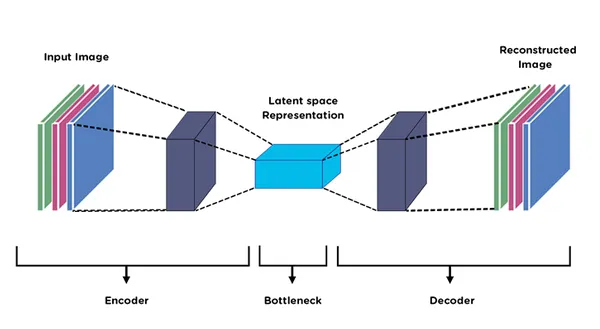

*https://medium.com/@birla.deepak26/autoencoders-76bb49ae6a8f*

**Definition**: An autoencoder is a type of neural network architecture designed to efficiently compress (encode) input data down to its essential features, then reconstruct (decode) the original input from this compressed representation.

In the mid-1980s, researchers were trying to understand how neural networks could learn internal representations of data without supervision. In 1986, Rumelhart, Hinton, and Williams published their seminal work on backpropagation, showing how neural networks could be trained to reconstruct their own inputs—what we now call autoencoding. However, it was in 1988 that Bourlard and Kamp formally analyzed this idea and proved that a linear autoencoder trained to minimize reconstruction error is mathematically equivalent to Principal Component Analysis (PCA). This theoretical grounding bridged neural networks and classical statistics, cementing autoencoders as a foundational concept in unsupervised learning.

**Reference**: https://publications.idiap.ch/downloads/reports/2000/rr00-16.pdf

**Why**: To discover meaningful structure in input data without labels.

**How**: It uses an encoder (to compress) and decoder (to reconstruct).

**Use Cases**:
- Dimensionality reduction
- Image compression
- Anomaly detection


In [ ]:
input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train_flat, x_train_flat, epochs=10, batch_size=256, validation_data=(x_test_flat, x_test_flat))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0958 - val_loss: 0.0324
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0291 - val_loss: 0.0208
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0195 - val_loss: 0.0151
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0144 - val_loss: 0.0116
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0113 - val_loss: 0.0093
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0091 - val_loss: 0.0078
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0077 - val_loss: 0.0067
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0067 - val_loss: 0.0059
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0060 - val_loss: 0.0054
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0055 - val_loss: 0.0051


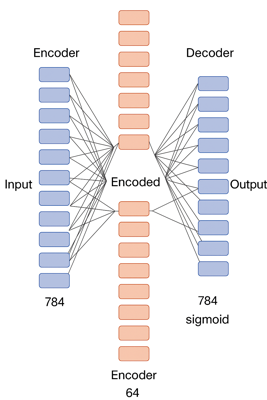

In [ ]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,602 (1.16 MB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 202,402 (790.64 KB)

The model takes a 784-dim input, compresses it to 64 dimensions using ReLU, and then expands back to 784 using sigmoid. This bottleneck forces the model to learn only the essential features needed to reconstruct the image.


#### Comparision between original and reconstructed images

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


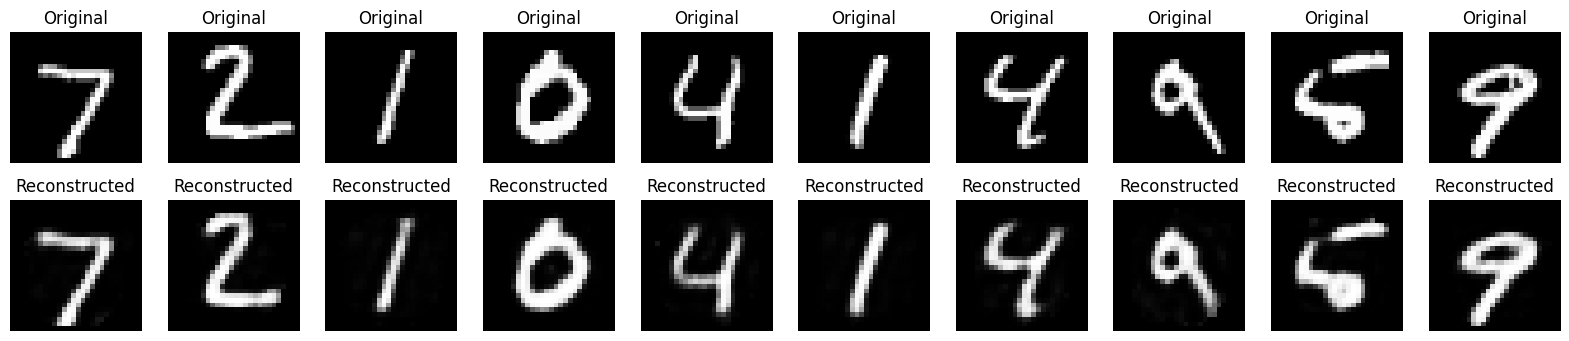

In [ ]:
import matplotlib.pyplot as plt

# Predict reconstructed images
decoded_imgs = autoencoder.predict(x_test_flat)

# Display original vs reconstructed
n = 10  # how many digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()


#### Separate Encoder and Decoder models

In [ ]:
# Define encoder model separately
encoder = Model(input_img, encoded)

# Define decoder model separately
encoded_input = Input(shape=(64,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))


In [ ]:
# Get compressed representation
encoded_imgs = encoder.predict(x_test_flat)

# Reconstruct using decoder only
reconstructed = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step


#### Step 1. original image

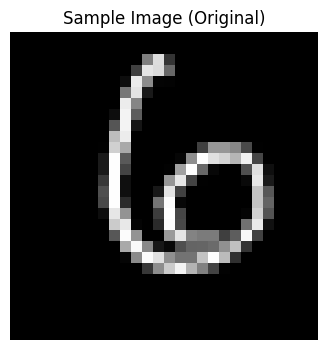

In [ ]:
# Get the first image
sample_img = x_test_flat[100].reshape(1, -1)  # shape (1, 784)

plt.figure(figsize=(4, 4))
plt.imshow(sample_img.reshape(28, 28), cmap='gray')
plt.title("Sample Image (Original)")
plt.axis('off')
plt.show()




#### Step 2. Codings (Latent vector)

In [ ]:

# Pass through encoder
latent_vector = encoder.predict(sample_img)
print("Latent vector shape:", latent_vector.shape)
print(latent_vector)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Latent vector shape: (1, 64)
[[2.372802   2.7295067  2.173259   5.831563   2.5131674  6.7990084
  5.024212   4.6590934  9.986867   3.057601   2.236515   1.0176396
  6.116842   0.79456204 1.7030463  2.3765233  3.0791407  3.024763
  2.0172572  3.4759355  2.9614186  7.2749195  5.139605   0.59327674
  6.962079   2.7295918  2.986565   1.3770276  3.5167143  4.157817
  0.         2.7512612  1.2247758  4.280355   3.4225373  5.252343
  4.726589   2.9184062  3.8680124  3.1620557  5.5887384  2.2919028
  5.5449123  4.697157   4.257988   4.0056934  2.3832617  2.9565206
  7.176363   4.7367473  7.378479   4.865736   4.039052   5.6648088
  4.500246   4.103375   3.6876945  1.0660462  3.9857733  2.4988441
  4.895999   5.805207   7.352254   4.7239923 ]]


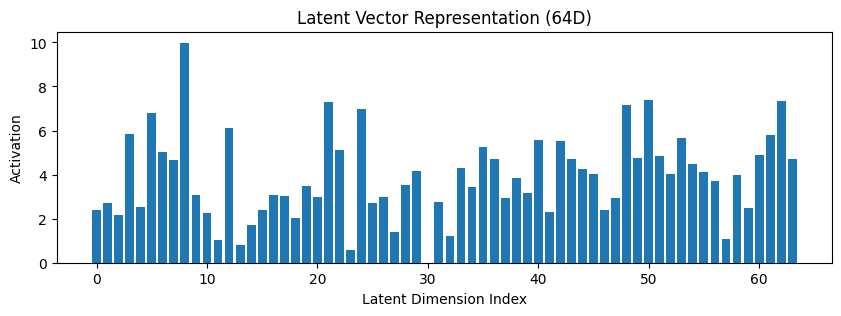

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
plt.bar(range(64), latent_vector[0])
plt.title("Latent Vector Representation (64D)")
plt.xlabel("Latent Dimension Index")
plt.ylabel("Activation")
plt.show()


### What does the latent vector plot show?

This plot shows the 64-dimensional latent vector produced by the encoder for one input image. Each bar represents one neuron in the bottleneck (latent) layer. The height of the bar tells us how much that neuron was activated — meaning how important that feature was for representing the image. Since we used ReLU activation, all values are 0 or positive. If a bar is zero, that feature didn’t get used for this image. So, this plot is like a compressed version or fingerprint of the original image that the autoencoder will use to reconstruct it.


#### Step 3. Reconstruct image from latent vector

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


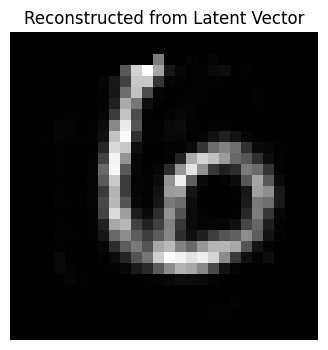

In [ ]:
# Decode the latent vector back to image
reconstructed_img = decoder.predict(latent_vector)

plt.figure(figsize=(4, 4))
plt.imshow(reconstructed_img.reshape(28, 28), cmap='gray')
plt.title("Reconstructed from Latent Vector")
plt.axis('off')
plt.show()

# Why Autoencoders in NLP? — Connection to Embeddings

Autoencoders are **representation learners** — they learn to **compress and reconstruct** data.  
In NLP, this means taking a large sparse text vector (like Bag-of-Words) and finding a **dense latent vector** that captures its meaning.

---

## 🔹 Analogy: Autoencoder = Learned Compression

| Step | Role | Operation | Example Shape |
|------|------|------------|----------------|
| **Input** | Original text as multi-hot (BoW) | 5 000-dim vector | `[0, 1, 0, 1, 0, …]` |
| **Encoder** | Learns to compress it | 5 000 → 512 → 64 | |
| **Latent Vector** | **Dense document representation** | 64-dim | `[0.3, −0.7, 1.1, …]` |
| **Decoder** | Reconstructs the input | 64 → 512 → 5 000 | |
| **Output** | Reconstructed BoW | 5 000-dim | ≈ input |

<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/2/28/Autoencoder_structure.png" width="70%">
</p>

*(Image: Encoder → latent (bottleneck) → decoder reconstruction, from Wikimedia Commons)*

---

## 🔹 Relationship to Embeddings

| Concept | Learns Representation For | Trained By Predicting |
|----------|---------------------------|------------------------|
| **Word Embedding** (Word2Vec, GloVe) | Each **word** | Neighboring words / context |
| **Autoencoder** (BoW or Sequence) | Each **document / sentence** | Itself (reconstruction) |

Both learn **dense semantic representations**, but:
- Word2Vec learns *word-level* meaning from **context**.  
- Autoencoders learn *document-level* meaning from **reconstruction**.

---

- Bridges **PCA intuition** to **neural embeddings**.  
- Demonstrates that **compression = representation learning**.  
- Sets up the logic for **denoising** and **transformer encoders**.

> The latent vector is effectively a **document embedding** learned without labels —  
> similar in spirit to how **BERT** learns contextual embeddings.


# NLP — Bag-of-Words Autoencoder (IMDB)

Similar autoencoding idea on **text**: compress a sparse **bag-of-words** vector into a low-dimensional latent space and reconstruct it. This mirrors the “undercomplete/PCA-like” intuition we use for MNIST.

**Plan.**
1. Load a small **IMDB reviews** subset (built-in to Keras).
2. Convert sequences to **multi-hot (BoW)** vectors over a small vocabulary (e.g., 5k words).
3. Train a tiny **Dense → latent → Dense** autoencoder with **sigmoid** outputs (reconstruct multi-hot).
4. Evaluate by comparing **top-k words** in input vs reconstruction and visualizing **latent 2-D**.



In [1]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
import numpy as np

# Limit vocab size to make demo quick
vocab_size = 5000
max_words = 500  # truncate / pad reviews to first 500 words

# Load IMDB dataset (already tokenized as word indices)
(x_train, _), (x_test, _) = imdb.load_data(num_words=vocab_size)

# Convert each review to a multi-hot (bag-of-words) vector
def to_multihot(sequences, dimension=vocab_size):
    results = np.zeros((len(sequences), dimension))
    for i, seq in enumerate(sequences):
        results[i, np.unique(seq)] = 1.0
    return results

x_train_bow = to_multihot(x_train)
x_test_bow  = to_multihot(x_test)

print("Train shape:", x_train_bow.shape)
print("Test shape :", x_test_bow.shape)
print("Example vector (first 20 dims):", x_train_bow[0][:20])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (25000, 5000)
Test shape : (25000, 5000)
Example vector (first 20 dims): [0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]


Bag-of-Words autoencoder:

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, optimizers, losses
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# Expect x_train_bow, x_test_bow to be defined from the previous cell
input_dim = x_train_bow.shape[1]  # = vocab_size
latent_dim = 64                   # small bottleneck for PCA-like intuition

# ----- Model -----
inputs = layers.Input(shape=(input_dim,), name="bow_input")
x = layers.Dense(512, activation="relu")(inputs)
x = layers.Dropout(0.1)(x)
x = layers.Dense(256, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="linear", name="latent")(x)  # linear works well for representation learning

x = layers.Dense(256, activation="relu")(latent)
x = layers.Dropout(0.1)(x)
x = layers.Dense(512, activation="relu")(x)
outputs = layers.Dense(input_dim, activation="sigmoid", name="reconstruction")(x)

autoencoder = Model(inputs, outputs, name="bow_autoencoder")
autoencoder.compile(
    optimizer=optimizers.Adam(1e-3),
    loss=losses.BinaryCrossentropy(),
    metrics=["binary_accuracy"]
)

autoencoder.summary()

# ----- Training -----
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    x_train_bow, x_train_bow,              # reconstruct input
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

print("Best val_loss:", np.min(history.history["val_loss"]))


Model: "bow_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bow_input (InputLayer)          │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,560,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 5000)           │     2,565,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,421,512 (20.68 MB)

 Trainable params: 5,421,512 (20.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 25s 258ms/step - binary_accuracy: 0.9249 - loss: 0.2508 - val_binary_accuracy: 0.9779 - val_loss: 0.0801
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 41s 255ms/step - binary_accuracy: 0.9782 - loss: 0.0794 - val_binary_accuracy: 0.9786 - val_loss: 0.0783
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 30s 346ms/step - binary_accuracy: 0.9789 - loss: 0.0776 - val_binary_accuracy: 0.9787 - val_loss: 0.0778
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 254ms/step - binary_accuracy: 0.9790 - loss: 0.0770 - val_binary_accuracy: 0.9788 - val_loss: 0.0770
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 234ms/step - binary_accuracy: 0.9791 - loss: 0.0767 - val_binary_accuracy: 0.9788 - val_loss: 0.0769
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 42s 248ms/step - binary_accuracy: 0.9791 - loss: 0.0768 - val_binary_accuracy: 0.9788 - val_loss: 0.0767
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 236ms/step - binary_accuracy: 0.9791 - loss: 0.0770 - val_binary_accuracy: 0.9788 - val_loss: 0.0768

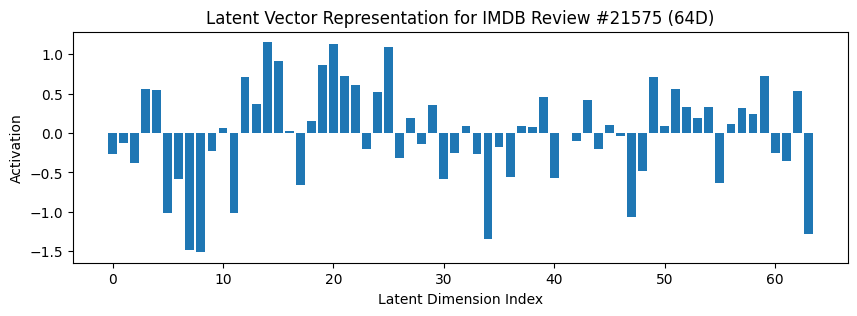

In [10]:
# Latent Vector Visualization for IMDB Review (64D bottleneck)

import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import Model

# build a separate encoder model to extract the latent vector
encoder = Model(autoencoder.input, autoencoder.get_layer("latent").output)

# pick one random test sample
idx = np.random.randint(len(x_test_bow))
x_in = x_test_bow[idx:idx+1]

# get the latent vector
latent_vector = encoder.predict(x_in, verbose=0)

plt.figure(figsize=(10, 3))
plt.bar(range(latent_vector.shape[1]), latent_vector[0])
plt.title(f"Latent Vector Representation for IMDB Review #{idx} (64D)")
plt.xlabel("Latent Dimension Index")
plt.ylabel("Activation")
plt.show()


In [18]:
# Use the decoder directly from your trained autoencoder

from tensorflow.keras import Model, Input
import numpy as np

# we already have autoencoder and encoder from before
latent_dim = encoder.output_shape[1]

# define a new input for the decoder (same latent size)
latent_input = Input(shape=(latent_dim,))

# find index of the latent layer in the autoencoder
layer_names = [layer.name for layer in autoencoder.layers]
latent_index = layer_names.index("latent")

# pass the new latent_input through the layers after latent
x = latent_input
for layer in autoencoder.layers[latent_index + 1:]:
    x = layer(x)
decoder = Model(latent_input, x, name="decoder")

# now decode your latent_vector
reconstructed = decoder.predict(latent_vector, verbose=0)

print("latent_vector shape:", latent_vector.shape)
print("reconstructed shape:", reconstructed.shape)



latent_vector shape: (1, 64)
reconstructed shape: (1, 5000)


In [19]:
# Show what was reconstructed: words (input vs output) + top-k by probability

from tensorflow.keras.datasets import imdb
import numpy as np

# --- mapping from indices -> words (respect IMDB's +3 offset and our vocab_size) ---
word_index = imdb.get_word_index()
index_to_word = {rank+3: word for word, rank in word_index.items() if (rank+3) < vocab_size}
index_to_word.update({0:"<PAD>", 1:"<START>", 2:"<OOV>", 3:"<UNUSED>"})
def idx2word(i): return index_to_word.get(int(i), f"#{int(i)}")

vec_in  = x_in[0]
vec_out = reconstructed[0]

# binary reconstruction for readability
threshold = 0.5
vec_out_bin = (vec_out >= threshold).astype(int)

# words present in input / reconstructed output
in_idxs  = np.where(vec_in == 1)[0]
out_idxs = np.where(vec_out_bin == 1)[0]

in_words  = [idx2word(i) for i in in_idxs]
out_words = [idx2word(i) for i in out_idxs]

print("INPUT words (first 10):")
print(in_words[:10], "\n")

print(f"RECONSTRUCTED words (threshold ≥ {threshold}, first 10):")
print(out_words[:10], "\n")



INPUT words (first 10):
['<START>', '<OOV>', 'the', 'and', 'a', 'of', 'to', 'is', 'br', 'in'] 

RECONSTRUCTED words (threshold ≥ 0.5, first 10):
['<START>', '<OOV>', 'the', 'and', 'a', 'of', 'to', 'is', 'br', 'in'] 



## Undercomplete Autoencoder (PCA-like)

#### What is an Undercomplete Autoencoder?

An undercomplete autoencoder is a type of autoencoder where the latent (bottleneck) layer has **fewer dimensions than the input**. This forces the network to compress the data and keep only the most essential features needed for reconstruction.

This is similar to how **PCA** works: by projecting high-dimensional data into a lower-dimensional space while preserving important information.



### Why use Undercomplete Autoencoders?

Imagine you’re working with handwritten digits like MNIST. Each image has 784 pixels, but most of them are blank or redundant. We don’t need all 784 numbers to understand what digit it is.

An undercomplete autoencoder helps us **compress** the image into fewer numbers — say 32 or 64 — while still being able to reconstruct the digit. It learns **what's essential**.

Real-world example: In mobile or embedded systems where memory and power are limited, we may want to **compress sensor or image data** before storing or transmitting it. Undercomplete autoencoders give us a trainable way to do that — better than hand-crafted features.


### What is PCA?

**Principal Component Analysis (PCA)** is a statistical technique used for **dimensionality reduction**. It finds a new set of axes (called principal components) that capture the most variance in the data.

PCA is commonly used to:
- Visualize high-dimensional data (like images)
- Remove noise
- Reduce computational cost for downstream models

Think of PCA as a mathematical way to **flatten** the data onto the directions that matter most — like turning a 3D object to see its most informative side.


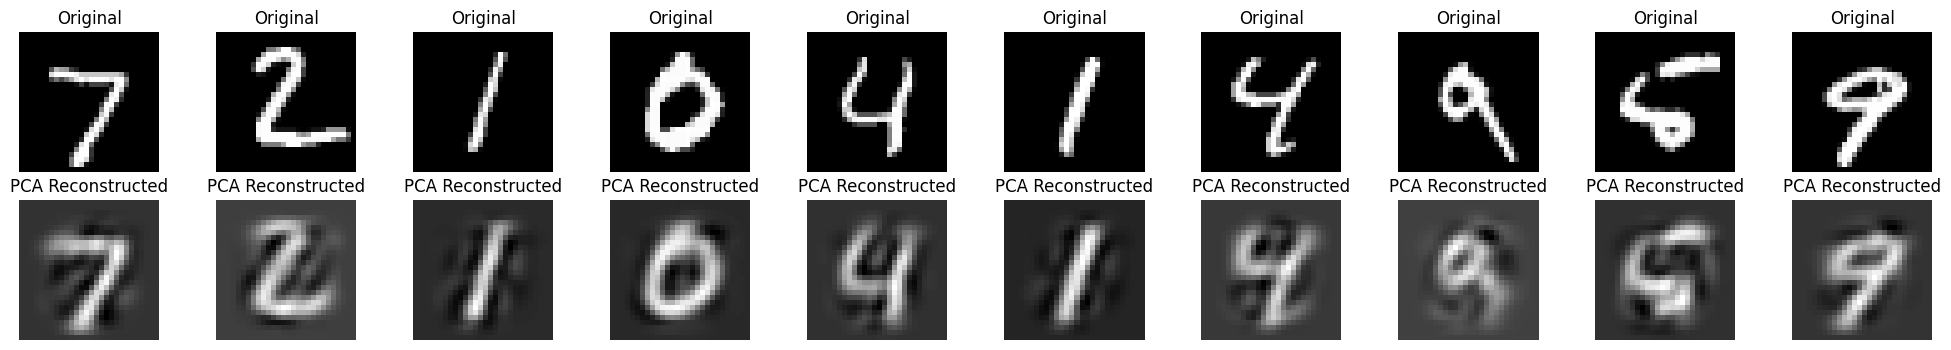

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

# Fit PCA on training data
pca = PCA(n_components=32)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)

# Reconstruct from PCA
x_test_pca_reconstructed = pca.inverse_transform(x_test_pca)

# Show original vs PCA-reconstructed
n = 10
plt.figure(figsize=(25, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_pca_reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title("PCA Reconstructed")
    plt.axis('off')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step


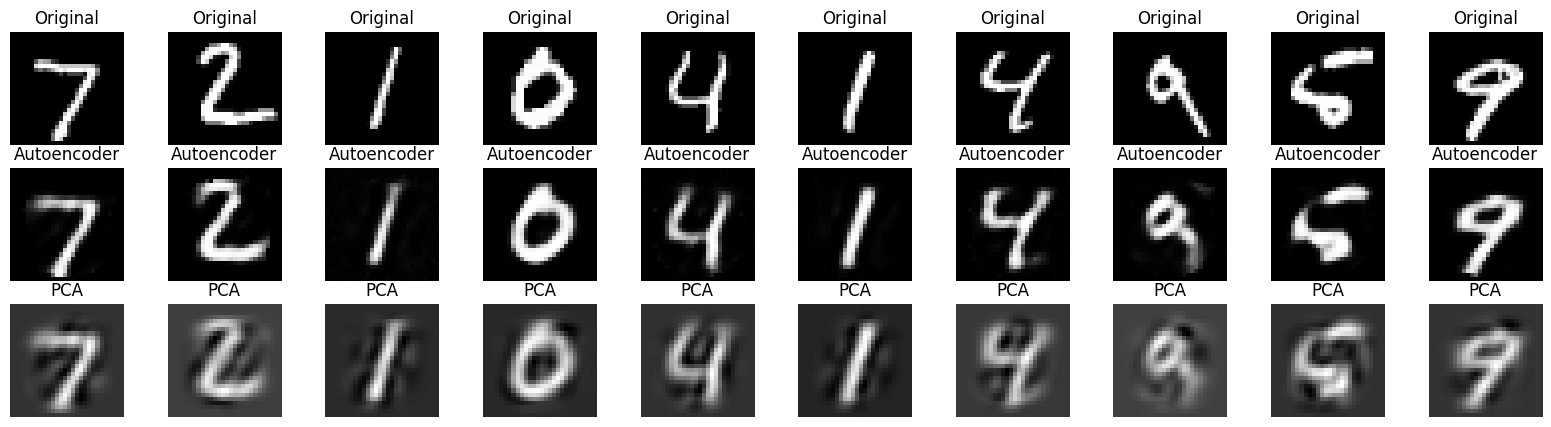

In [ ]:
# Build Undercomplete Autoencoder (same latent size as PCA)
input_img = Input(shape=(784,))
encoded = Dense(32, activation='linear')(input_img)  # linear activation
decoded = Dense(784, activation='sigmoid')(encoded)

undercomplete_autoencoder = Model(input_img, decoded)
undercomplete_autoencoder.compile(optimizer='adam', loss='mse')

history = undercomplete_autoencoder.fit(x_train_flat, x_train_flat,
                                        epochs=10,
                                        batch_size=256,
                                        validation_data=(x_test_flat, x_test_flat),
                                        verbose=0)

# Reconstruct
autoencoded_imgs = undercomplete_autoencoder.predict(x_test_flat)

# Compare visually
plt.figure(figsize=(20, 5))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Autoencoder
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(autoencoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Autoencoder")
    plt.axis('off')

    # PCA
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test_pca_reconstructed[i].reshape(28, 28), cmap='gray')
    plt.title("PCA")
    plt.axis('off')
plt.show()


#### Comparison PCA latent spaces vs. Encoder codings

In [ ]:
# Encoder
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
bottleneck = Dense(2, activation='linear')(encoded)  # <-- 2D latent space

# Decoder
decoded = Dense(128, activation='relu')(bottleneck)
output = Dense(784, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder_2d = Model(input_img, output)
autoencoder_2d.compile(optimizer='adam', loss='mse')

# Train
autoencoder_2d.fit(x_train_flat, x_train_flat,
                   epochs=20,
                   batch_size=256,
                   shuffle=True,
                   validation_data=(x_test_flat, x_test_flat),
                   verbose=1)

# Create encoder model to get 2D latent codes
encoder_2d = Model(input_img, bottleneck)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1013 - val_loss: 0.0584
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0573 - val_loss: 0.0539
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0535 - val_loss: 0.0507
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0504 - val_loss: 0.0483
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0484 - val_loss: 0.0473
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0474 - val_loss: 0.0466
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0467 - val_loss: 0.0461
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0462 - val_loss: 0.0457
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0458 - val_loss: 0.0453
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0455 - val_loss: 0.0450
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0450 - val_loss: 0.0447
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/st

In [ ]:
latent_2d_codes = encoder_2d.predict(x_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step


In [ ]:
pca_2d = PCA(n_components=2)
x_test_pca_2d = pca_2d.fit_transform(x_test_flat)


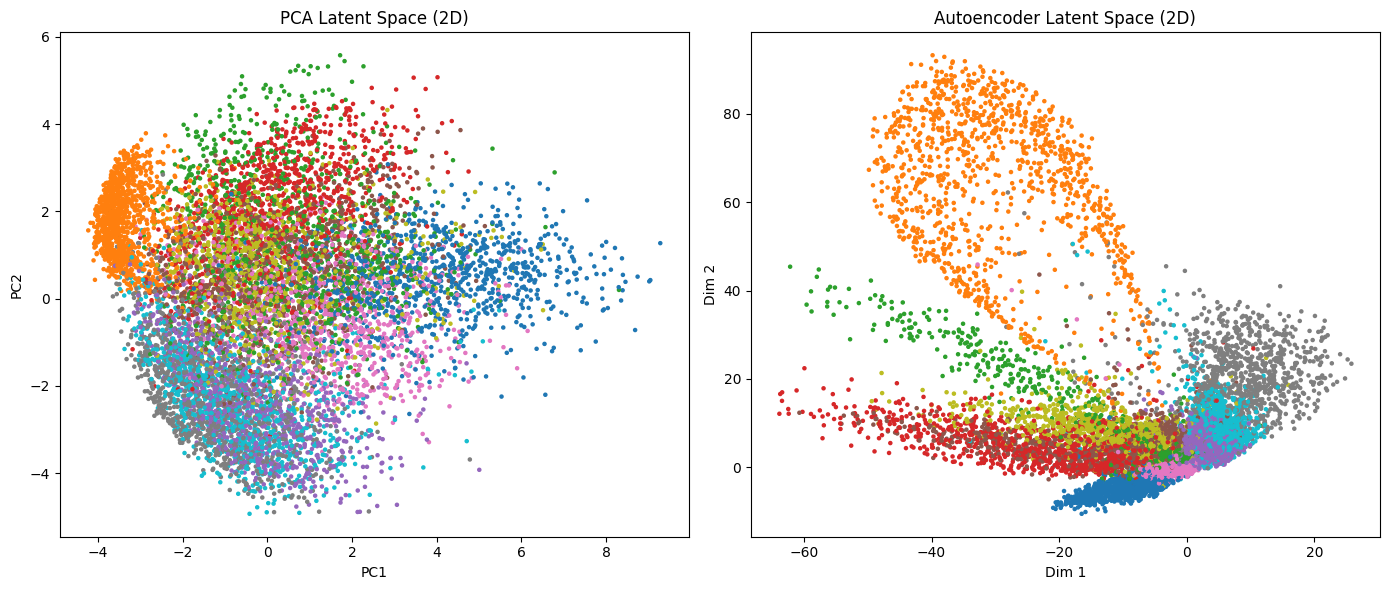

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA 2D plot
axes[0].scatter(x_test_pca_2d[:, 0], x_test_pca_2d[:, 1], c=y_test, cmap='tab10', s=5)
axes[0].set_title("PCA Latent Space (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Autoencoder 2D plot
axes[1].scatter(latent_2d_codes[:, 0], latent_2d_codes[:, 1], c=y_test, cmap='tab10', s=5)
axes[1].set_title("Autoencoder Latent Space (2D)")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

### Comparing PCA vs Autoencoder Latent Spaces (2D)

The left plot shows the 2D latent space created by **PCA** (Principal Component Analysis), a linear dimensionality reduction technique. It captures variance but treats all directions equally. The result is a flat, overlapping projection — useful, but not very structured.

The right plot shows the 2D latent space learned by a **nonlinear autoencoder**, trained specifically to reconstruct the input digits. You can see much clearer separation between digit clusters. This means the autoencoder is learning a more meaningful representation of the data, capturing complex structures that PCA cannot.

In summary:
- **PCA**: fast and interpretable, but limited to linear structure
- **Autoencoder**: slower to train, but produces a **richer and more discriminative latent space**


## Stacked Autoencoder

### What is a Stacked Autoencoder?

A stacked autoencoder is a deep version of an autoencoder — it has **multiple encoding and decoding layers** stacked on top of each other.

Instead of just compressing and decompressing in a single step, stacked autoencoders **learn a hierarchy of features** — starting from low-level patterns and building up to higher-level abstractions.

More layers → more capacity to learn complex structure.



In [ ]:
input_img = Input(shape=(784,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(32, activation='relu')(encoded)

decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

stacked = Model(input_img, decoded)
stacked.compile(optimizer='adam', loss='mse')
stacked.fit(x_train_flat, x_train_flat, epochs=10, batch_size=256, validation_data=(x_test_flat, x_test_flat))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0952 - val_loss: 0.0390
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0354 - val_loss: 0.0265
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0259 - val_loss: 0.0222
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0222 - val_loss: 0.0202
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0203 - val_loss: 0.0183
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0185 - val_loss: 0.0167
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0170 - val_loss: 0.0157
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0160 - val_loss: 0.0150
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0151 - val_loss: 0.0144
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0145 - val_loss: 0.0139


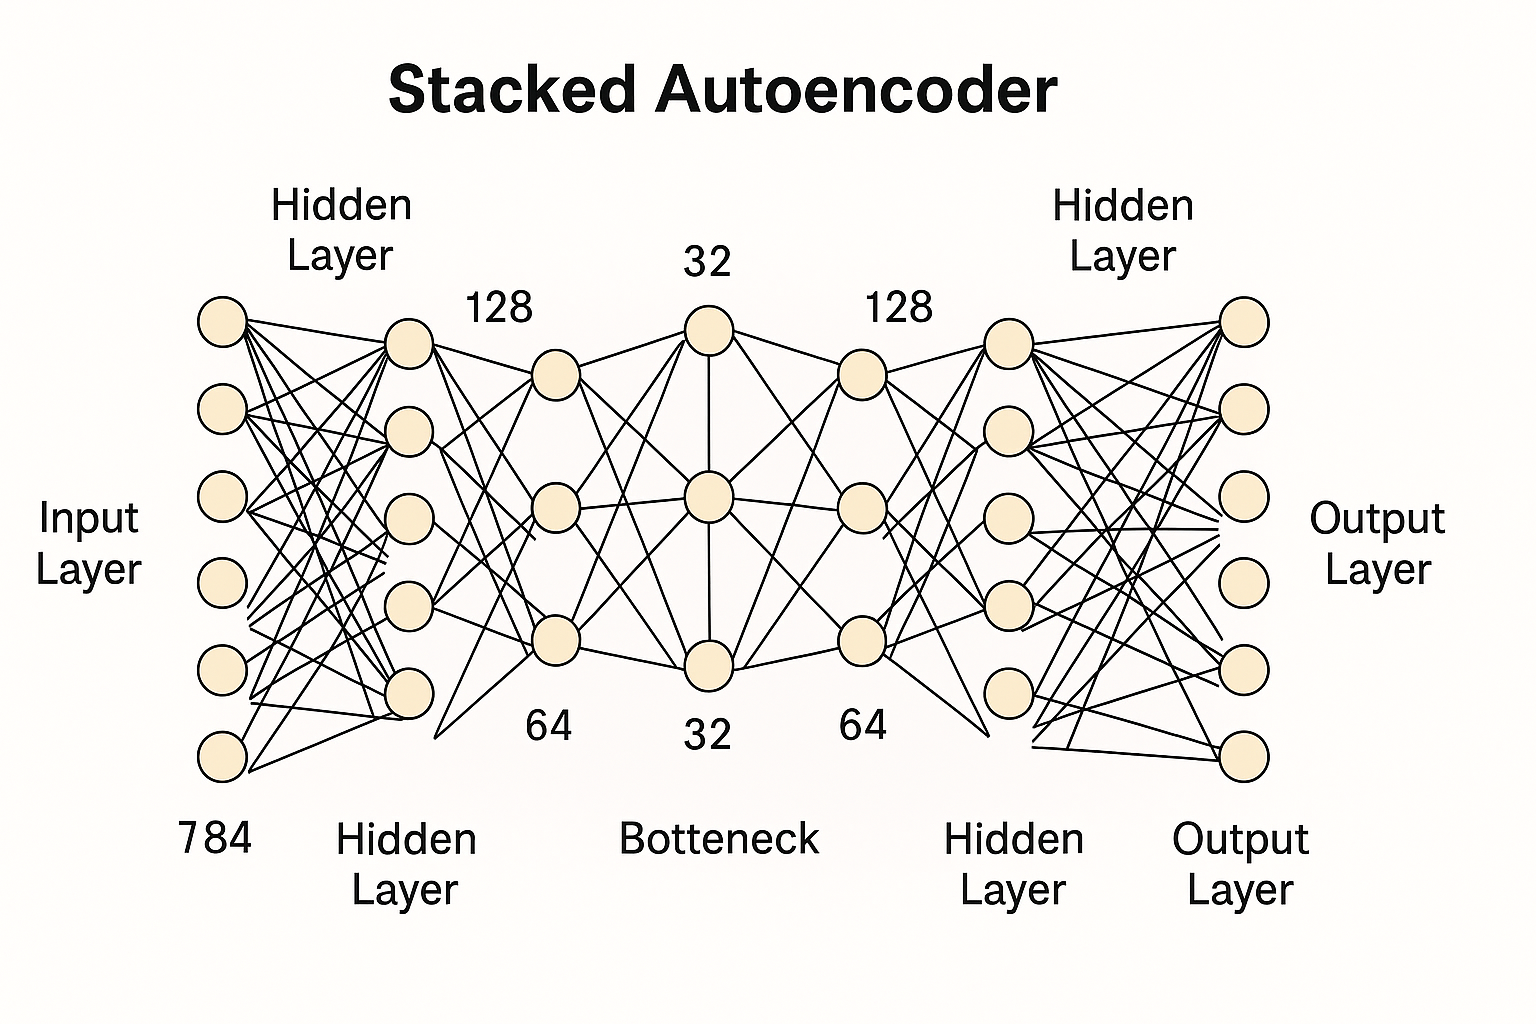

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


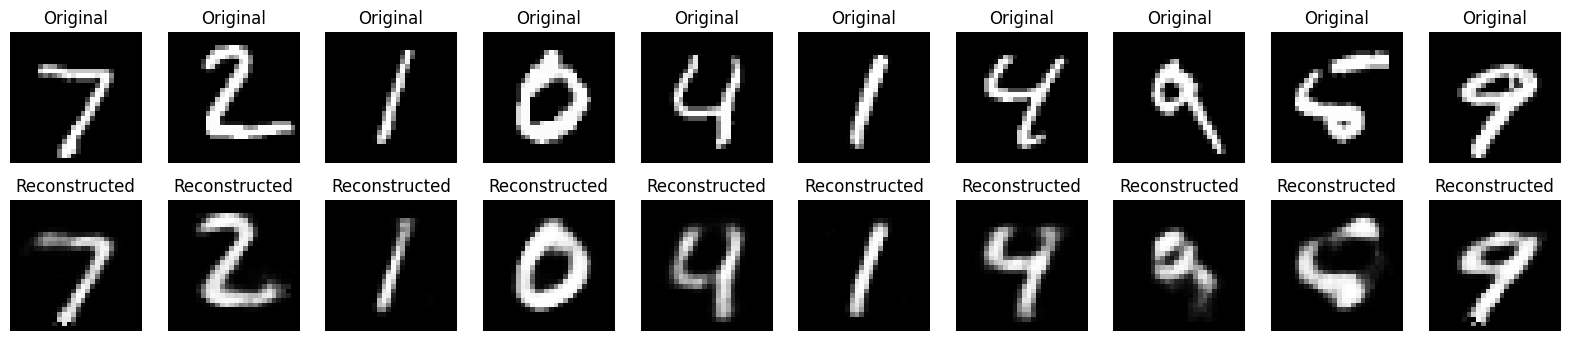

In [ ]:
decoded_imgs = stacked.predict(x_test_flat)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()


### Visualizing Latent Space with t-SNE

**t-SNE (t-distributed Stochastic Neighbor Embedding)** is a dimensionality reduction technique used for **visualizing high-dimensional data in 2D or 3D**.

It works by preserving the **local structure** of data — so points that are close in high-dimensional space remain close in the 2D plot.

In this example, we apply t-SNE to the **32-dimensional latent vectors** learned by our stacked autoencoder. Each point represents an input image, and the color shows its digit label.

- If t-SNE forms clear, tight clusters by digit, it means the autoencoder is learning **meaningful compressed features**.
- Overlap between classes may suggest the model is still learning or that the latent space isn’t fully disentangled yet.

t-SNE is commonly used to inspect **learned embeddings**, **hidden representations**, or **clustering quality** in deep learning models.


In [ ]:
# Define encoder model (input → 32D bottleneck layer)
encoder = Model(inputs=input_img, outputs=encoded)

# Get latent vectors from test set (shape: [num_samples, 32])
latent_vectors = encoder.predict(x_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


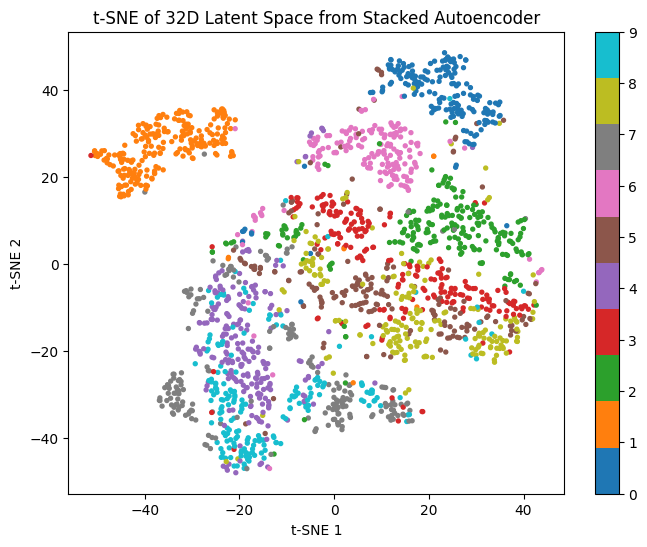

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE is computationally expensive — consider sampling 2000 points
sample_size = 2000
latent_sample = latent_vectors[:sample_size]
labels_sample = y_test[:sample_size]

# Run t-SNE
tsne = TSNE(n_components=2, learning_rate='auto', init='pca', perplexity=30, random_state=42)
latent_tsne = tsne.fit_transform(latent_sample)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], c=labels_sample, cmap='tab10', s=8)
plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE of 32D Latent Space from Stacked Autoencoder")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()


### Stacked vs Shallow Autoencoder

A stacked autoencoder has multiple hidden layers in both encoder and decoder, while a shallow autoencoder has just one each.

**Why stack?**  
Stacked autoencoders learn more powerful representations by building feature hierarchies. This leads to better performance on complex tasks like image reconstruction, feature extraction, or unsupervised pretraining.

| Aspect             | Shallow AE                | Stacked AE              |
|--------------------|---------------------------|--------------------------|
| Layers             | 1 encoder + 1 decoder     | Multiple encoder + decoder |
| Feature learning   | Shallow patterns          | Hierarchical features    |
| Capacity           | Limited                   | Higher                   |
| Use case           | Simple compression        | Complex representation   |


## Reusing and Freezing Layers in an Autoencoder (MNIST)

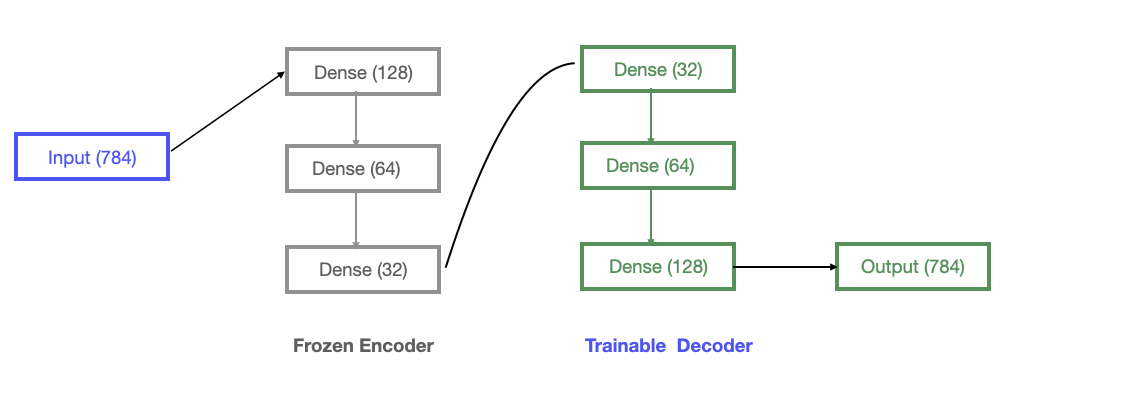

##### Train a full autoencoder

In [ ]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

# Encoder
encoder_input = Input(shape=(784,), name="encoder_input")
x = Dense(128, activation='relu', name="enc_dense_128")(encoder_input)
x = Dense(64, activation='relu', name="enc_dense_64")(x)
encoder_output = Dense(32, activation='relu', name="latent_vector")(x)

encoder = Model(inputs=encoder_input, outputs=encoder_output, name="Encoder")

# Decoder
decoder_input = Input(shape=(32,), name="decoder_input")
x = Dense(64, activation='relu', name="dec_dense_64")(decoder_input)
x = Dense(128, activation='relu', name="dec_dense_128")(x)
decoder_output = Dense(784, activation='sigmoid', name="decoder_output")(x)

decoder = Model(inputs=decoder_input, outputs=decoder_output, name="Decoder")

# Full Autoencoder = Encoder + Decoder
autoencoder_input = encoder_input  # same input
autoencoder_output = decoder(encoder(encoder_input))
autoencoder = Model(inputs=autoencoder_input, outputs=autoencoder_output, name="Autoencoder")

# Compile and train
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train_flat, x_train_flat,
                epochs=10, batch_size=256,
                validation_data=(x_test_flat, x_test_flat))



Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0983 - val_loss: 0.0368
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0344 - val_loss: 0.0273
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0264 - val_loss: 0.0224
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0219 - val_loss: 0.0198
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0195 - val_loss: 0.0179
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0180 - val_loss: 0.0166
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0167 - val_loss: 0.0155
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0157 - val_loss: 0.0147
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0149 - val_loss: 0.0141
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0142 - val_loss: 0.0136


##### Freeze encoder, attach a different decoder[link text](https://)

In [ ]:
# Freeze encoder
for layer in encoder.layers:
    layer.trainable = False

# Freeze the submodel itself
encoder.trainable = False

# NEW Decoder (different layers)
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
new_decoder_input = Input(shape=(32,), name="new_decoder_input")
x = Dense(64, activation='relu')(new_decoder_input)
x = Dropout(0.2)(x)  # Additional layer, helps denoising/generalization
x = Dense(128, activation='relu')(x)

decoder_output = Dense(784, activation='sigmoid')(x)

new_decoder = Model(inputs=new_decoder_input, outputs=decoder_output, name="EnhancedDecoder")

##### Build new model using frozen encoder + new decoder

In [ ]:
frozen_input = Input(shape=(784,), name="frozen_input")
frozen_latent = encoder(frozen_input)           # frozen encoder
reconstructed = new_decoder(frozen_latent)     # fresh decoder

frozen_autoencoder = Model(inputs=frozen_input, outputs=reconstructed, name="FrozenEncoderNewDecoder")
frozen_autoencoder.compile(optimizer='adam', loss='mse')

# Train: only decoder updates
frozen_autoencoder.fit(x_train_flat, x_train_flat,
                       epochs=10, batch_size=256,
                       validation_data=(x_test_flat, x_test_flat))



Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0892 - val_loss: 0.0253
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0306 - val_loss: 0.0200
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0269 - val_loss: 0.0186
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0253 - val_loss: 0.0176
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0246 - val_loss: 0.0172
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0239 - val_loss: 0.0166
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0235 - val_loss: 0.0163
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0232 - val_loss: 0.0161
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0228 - val_loss: 0.0159
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0225 - val_loss: 0.0156


In [ ]:
print("\nLayer-wise Trainable Flags:")
for layer in frozen_autoencoder.layers:
    print(f"{layer.name:<30} | trainable: {layer.trainable}")



Layer-wise Trainable Flags:
frozen_input                   | trainable: True
Encoder                        | trainable: False
EnhancedDecoder                | trainable: True


In [ ]:
frozen_autoencoder.summary()

Model: "FrozenEncoderNewDecoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frozen_input (InputLayer)       │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Functional)            │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ EnhancedDecoder (Functional)    │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 445,522 (1.70 MB)

 Trainable params: 111,568 (435.81 KB)

 Non-trainable params: 110,816 (432.88 KB)

 Optimizer params: 223,138 (871.64 KB)

##### Predict & Show Reconstructions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


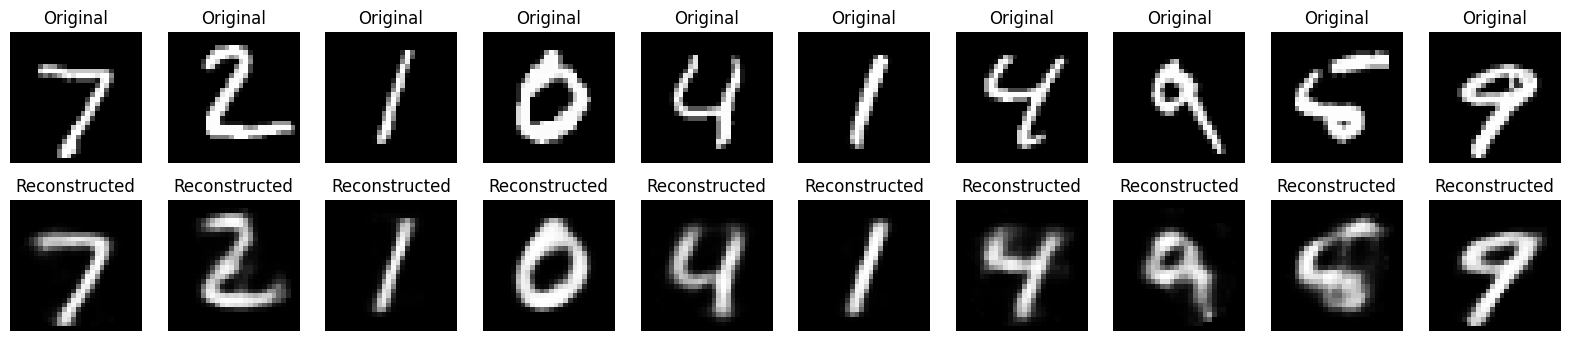

In [ ]:
decoded_imgs = frozen_autoencoder.predict(x_test_flat)

# Show original vs reconstructed images
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()


## Convolutional Autoencoder

**Definition**: Autoencoder that uses Conv2D layers instead of Dense layers. Preserves spatial features in image data.

**Why**: Images have local patterns (edges, textures). Dense layers ignore this. Convolutions are better suited.

**How it's different**: Instead of flattening inputs, this model works directly on 2D image shape with filters.

**Use Cases**:
- Denoising images
- Anomaly detection in visual data (e.g., manufacturing)
- Unsupervised feature learning from images


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import numpy as np

# Load data
(x_train, _), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Reshape for Conv2D
x_train_exp = x_train.reshape(-1, 28, 28, 1)
x_test_exp = x_test.reshape(-1, 28, 28, 1)

# --- ENCODER ---
input_img = Input(shape=(28, 28, 1), name='CAE_Input')

x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)       # 28x28x16
x = MaxPooling2D((2, 2), padding='same')(x)                                 # 14x14x16
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)                # 14x14x8
x = MaxPooling2D((2, 2), padding='same')(x)                                 # 7x7x8
encoded = Conv2D(8, (3, 3), activation='relu', padding='same', name='Latent_Space')(x)  # 7x7x8

# --- DECODER ---
x = UpSampling2D((2, 2))(encoded)                                           # 14x14x8
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)                # 14x14x8
x = UpSampling2D((2, 2))(x)                                                 # 28x28x8
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)       # 28x28x1

# --- MODELS ---
autoencoder = Model(input_img, decoded, name="CAE_Model")
encoder = Model(input_img, encoded, name="CAE_Encoder")

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()


Model: "CAE_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CAE_Input (InputLayer)          │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Space (Conv2D)           │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │            73 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

### Convolutional Autoencoder Architecture

```
Input (28×28×1)
      │
Conv2D (16 filters, 3×3, relu, same) → Output: 28×28×16
      │
MaxPooling2D (2×2, same)              → Output: 14×14×16
      │
Conv2D (8 filters, 3×3, relu, same)  → Output: 14×14×8
      │
MaxPooling2D (2×2, same)              → Output: 7×7×8
      │
Conv2D (8 filters, 3×3, relu, same)  → Output: 7×7×8
      │
UpSampling2D (2×2)                    → Output: 14×14×8
      │
Conv2D (8 filters, 3×3, relu, same)  → Output: 14×14×8
      │
UpSampling2D (2×2)                    → Output: 28×28×8
      │
Conv2D (1 filter, 3×3, sigmoid, same)→ Output: 28×28×1
      ↓
Reconstructed Image
```



In [ ]:
autoencoder.fit(x_train_exp, x_train_exp,
                epochs=10,
                batch_size=128,
                validation_data=(x_test_exp, x_test_exp))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 35s 72ms/step - loss: 0.2554 - val_loss: 0.1029
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - loss: 0.1004 - val_loss: 0.0912
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - loss: 0.0908 - val_loss: 0.0863
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 72ms/step - loss: 0.0866 - val_loss: 0.0837
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 69ms/step - loss: 0.0839 - val_loss: 0.0815
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 74ms/step - loss: 0.0820 - val_loss: 0.0801
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - loss: 0.0807 - val_loss: 0.0792
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - loss: 0.0799 - val_loss: 0.0781
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - loss: 0.0787 - val_loss: 0.0772
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - loss: 0.0779 - val_loss: 0.0765


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step 


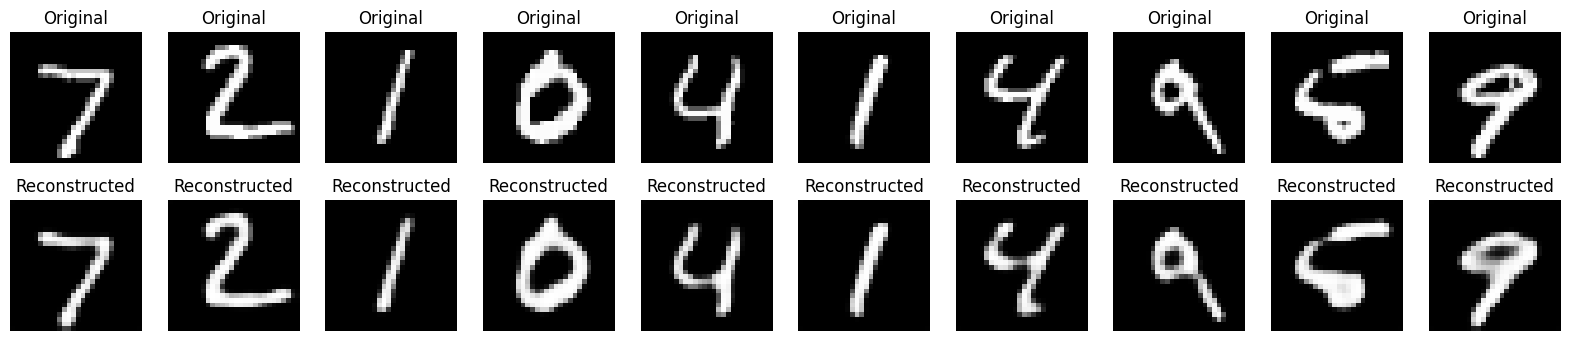

In [ ]:
decoded_imgs = autoencoder.predict(x_test_exp)

# Show original vs reconstructed images
import matplotlib.pyplot as plt

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_flat[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

##### Visualize Latent Feature Maps for One Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


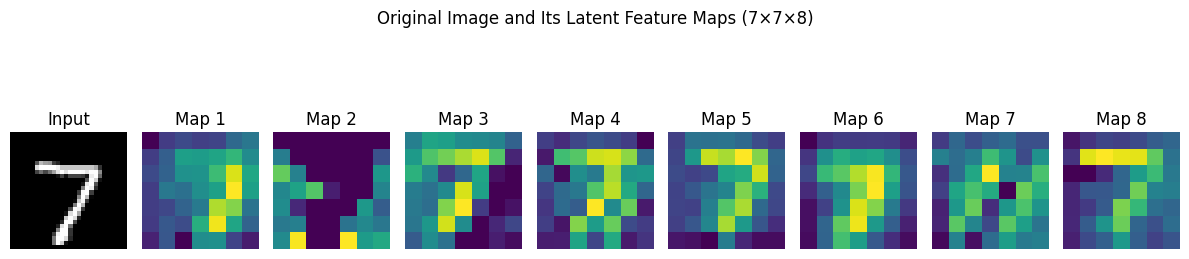

In [ ]:
import matplotlib.pyplot as plt

# Select an image from test set
idx = 0
sample_image = x_test_exp[idx:idx+1]  # shape: (1, 28, 28, 1)

# Get latent space output
latent_activations = encoder.predict(sample_image)  # shape: (1, 7, 7, 8)
feature_maps = latent_activations[0]  # shape: (7, 7, 8)

# Plot original image + 8 latent maps
plt.figure(figsize=(12, 3))

# Original image
plt.subplot(1, 9, 1)
plt.imshow(sample_image[0, :, :, 0], cmap='gray')
plt.title("Input")
plt.axis('off')

# Latent feature maps
for i in range(8):
    plt.subplot(1, 9, i + 2)
    plt.imshow(feature_maps[:, :, i], cmap='viridis')
    plt.title(f"Map {i+1}")
    plt.axis('off')

plt.suptitle("Original Image and Its Latent Feature Maps (7×7×8)", y=1.05)
plt.tight_layout()
plt.show()



Unlike Dense autoencoders, convolutional autoencoders preserve spatial information. Each of these 8 heatmaps is a feature map — it activates differently depending on the content in the image, like edges, blobs, or texture patterns. These are the compressed patterns that the decoder uses to reconstruct the input.

## Denoising Autoencoder

**Definition**: An autoencoder trained to reconstruct the original input from a **noisy version** of it.

**Why**: Forces the encoder to learn features that are **robust to noise** — not just to memorize.

**How it's different**: The training input is noisy, but the target output is clean.

**Use Cases**:
- Denoising images or signals
- Speech enhancement
- Robust representation learning


##### Prepare Noisy Inputs

In [ ]:
import numpy as np

# Add Gaussian noise
noise_factor = 0.5
x_train_noisy = x_train_exp + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train_exp.shape)
x_test_noisy = x_test_exp + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test_exp.shape)

# Clip to [0, 1] range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


This code is adding Gaussian noise to the image to make it blurry or messy.
We multiply the noise by a noise_factor (like 0.5) to control how strong the noise is — bigger value means more distortion.
After adding noise, some pixel values might go outside the valid range (like below 0 or above 1), so we use np.clip to limit all values back into the [0, 1] range.
This creates "noisy" input images that the Denoising Autoencoder will try to clean up and reconstruct as the original.

###### Visualize Noisy vs Original Inputs

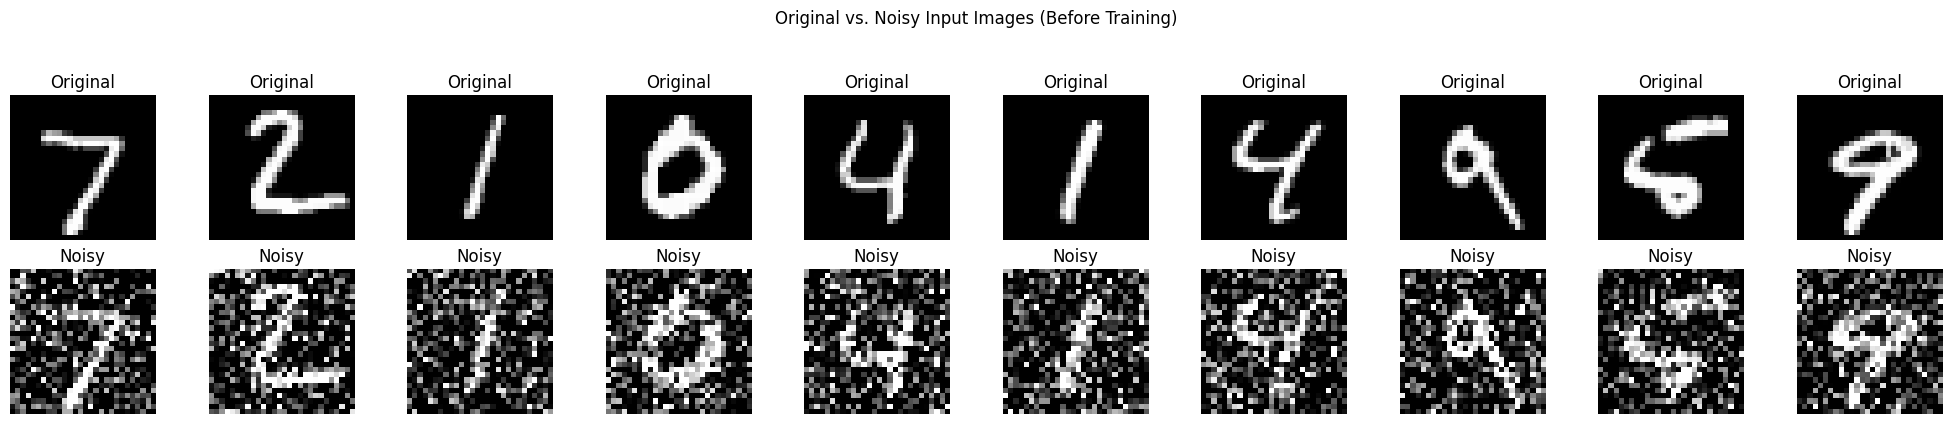

In [ ]:
import matplotlib.pyplot as plt

n = 10  # how many digits to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_exp[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Original vs. Noisy Input Images (Before Training)", y=1.05)
plt.tight_layout()
plt.show()


##### Reuse same CNN Autoencoder architecture

In [ ]:
# Train on noisy input → clean output
autoencoder.fit(x_train_noisy, x_train_exp,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test_exp))


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - loss: 0.1142 - val_loss: 0.1126
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 72ms/step - loss: 0.1134 - val_loss: 0.1116
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - loss: 0.1125 - val_loss: 0.1109
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 75ms/step - loss: 0.1119 - val_loss: 0.1105
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - loss: 0.1111 - val_loss: 0.1095
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 71ms/step - loss: 0.1107 - val_loss: 0.1090
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 75ms/step - loss: 0.1099 - val_loss: 0.1086
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - loss: 0.1095 - val_loss: 0.1081
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - loss: 0.1092 - val_loss: 0.1078
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - loss: 0.1088 - val_loss: 0.1075


##### Visualize Denoising Results

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


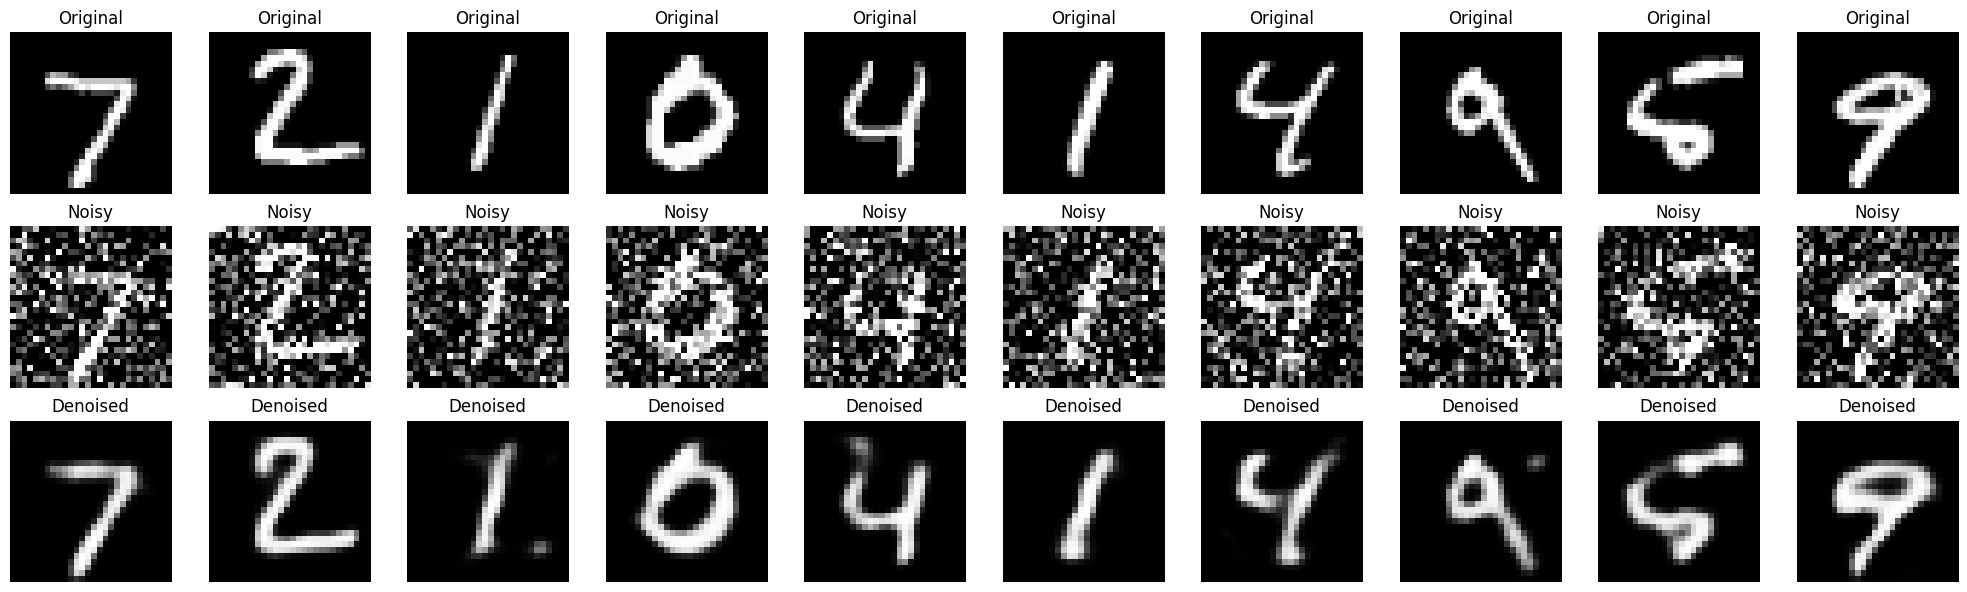

In [ ]:
import matplotlib.pyplot as plt

# Predict denoised images
denoised_imgs = autoencoder.predict(x_test_noisy)

# Display
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy input
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised (output)
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')



plt.tight_layout()
plt.show()


We deliberately add noise to the input but still ask the model to predict the clean image. This trains the network to focus on meaningful features and ignore noise — a powerful method to learn robust internal representations.